In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
)
from xgboost import XGBClassifier

print("✓ All libraries loaded!")


✓ All libraries loaded!


In [46]:
def load_geo_series(filepath):
    print(f"Loading {filepath}...")
    labels = []

    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('!Sample_characteristics_ch1'):
                parts = line.strip().split('\t')
                for p in parts[1:]:
                    p_lower = p.lower()
                    if 'alzheimer' in p_lower or ': ad' in p_lower:
                        labels.append(1)
                    elif 'control' in p_lower or 'ctl' in p_lower or 'healthy' in p_lower:
                        labels.append(0)
                    elif 'mci' in p_lower:
                        labels.append(2)
                    else:
                        labels.append(-1)
                break

    # Load gene expression matrix (skip metadata lines starting with '!')
    df = pd.read_csv(filepath, sep='\t', comment='!', index_col=0)
    df = df.T

    if len(labels) == len(df):
        df['Diagnosis'] = labels
    else:
        print(f"  ⚠ Label mismatch: {len(labels)} labels, {len(df)} samples")

    df = df[df['Diagnosis'].isin([0, 1])].copy()
    print(f"  ✓ {df.shape[0]} samples | {df.shape[1]-1:,} genes | "
          f"AD: {(df['Diagnosis']==1).sum()} | Control: {(df['Diagnosis']==0).sum()}")
    return df

# ── Load both datasets ────────────────────────────────────────────────────────
df1 = load_geo_series('GSE63060_series_matrix.txt')
df2 = load_geo_series('GSE63061_series_matrix.txt')

Loading GSE63060_series_matrix.txt...
  ✓ 249 samples | 38,323 genes | AD: 145 | Control: 104
Loading GSE63061_series_matrix.txt...
  ✓ 275 samples | 32,049 genes | AD: 139 | Control: 136


In [47]:
# Find common genes between both datasets
common_genes = df1.columns.intersection(df2.columns).tolist()
print(f"Common genes across both datasets: {len(common_genes)-1:,}")  # -1 for Diagnosis col

# Combine on common genes (including Diagnosis)
df_combined = pd.concat([df1[common_genes], df2[common_genes]], axis=0, ignore_index=True)

print(f"Combined dataset: {df_combined.shape[0]} samples × {df_combined.shape[1]-1:,} genes")
print(f"  AD      (1): {(df_combined['Diagnosis']==1).sum()}")
print(f"  Control (0): {(df_combined['Diagnosis']==0).sum()}")
print("✓ Datasets combined!")

Common genes across both datasets: 25,549
Combined dataset: 524 samples × 25,549 genes
  AD      (1): 284
  Control (0): 240
✓ Datasets combined!


In [48]:
X = df_combined.drop(columns=['Diagnosis'])
y = df_combined['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("✓ Data split complete!")

Training set: 393 samples
Test set:     131 samples
✓ Data split complete!


In [49]:
# Pipeline:
#  1. SelectKBest  — keep top 1000 genes by ANOVA F-value
#  2. StandardScaler — normalise
#  3. PCA           — reduce to 30 components
#  4. XGBoost       — classify

pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_classif, k=1000)),
    ('scaler',   StandardScaler()),
    ('pca',      PCA(n_components=30, random_state=42)),
    ('xgb',      XGBClassifier(
                    n_estimators=100,
                    learning_rate=0.1,
                    max_depth=4,
                    scale_pos_weight=240/284,  # Control/AD ratio
                    eval_metric='logloss',
                    random_state=42
                 ))
])

print("✓ Pipeline defined!")
print("  Steps: SelectKBest(k=1000) → StandardScaler → PCA(30) → XGBoost")


✓ Pipeline defined!
  Steps: SelectKBest(k=1000) → StandardScaler → PCA(30) → XGBoost


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost 5-Fold CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")
print("✓ Cross-validation complete!")


XGBoost 5-Fold CV ROC-AUC: 0.7954 ± 0.0282
✓ Cross-validation complete!


In [51]:
print("🔍 Running GridSearchCV...")
print("   (This may take several minutes due to gene expression data size...)\n")

param_grid = {
    'selector__k':           [500, 1000, 2000],
    'pca__n_components':     [20, 30, 50],
    'xgb__n_estimators':     [100, 200],
    'xgb__learning_rate':    [0.05, 0.10],
    'xgb__max_depth':        [3, 4],
    'xgb__subsample':        [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print(f"\n✓ Best parameters: {grid_search.best_params_}")
print(f"  Best CV AUC:     {grid_search.best_score_:.4f}")


🔍 Running GridSearchCV...
   (This may take several minutes due to gene expression data size...)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

✓ Best parameters: {'pca__n_components': 30, 'selector__k': 1000, 'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
  Best CV AUC:     0.8045


In [52]:
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Control", "Alzheimer's"]))


Accuracy: 0.7557251908396947
              precision    recall  f1-score   support

     Control       0.73      0.73      0.73        60
 Alzheimer's       0.77      0.77      0.77        71

    accuracy                           0.76       131
   macro avg       0.75      0.75      0.75       131
weighted avg       0.76      0.76      0.76       131



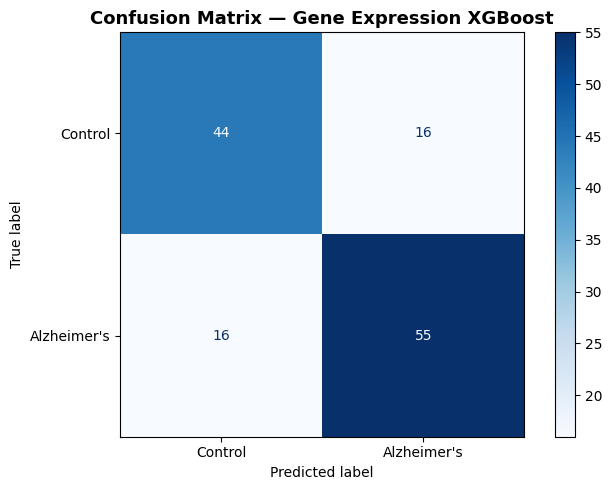

In [53]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Control", "Alzheimer's"],
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Gene Expression XGBoost",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


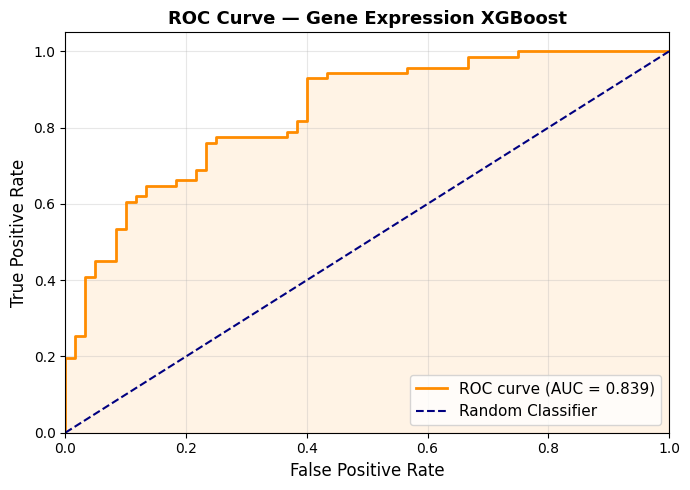

In [54]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--',
        label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title("ROC Curve — Gene Expression XGBoost",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Top 15 Genes by ANOVA F-Score:
        Gene     Score
ILMN_1652073 67.398026
ILMN_1656625 51.761838
ILMN_2290808 44.621888
ILMN_1755808 42.518455
ILMN_1755115 35.678640
ILMN_1677262 35.328201
ILMN_1667813 31.096456
ILMN_1755883 30.862823
ILMN_1754195 30.002489
ILMN_1696839 28.066625
ILMN_1728132 26.813545
ILMN_2189933 25.123443
ILMN_1711729 24.985768
ILMN_1731546 24.701192
ILMN_1675124 23.420619
Note: ILMN_* are Illumina probe IDs — map to gene symbols via annotation file if needed


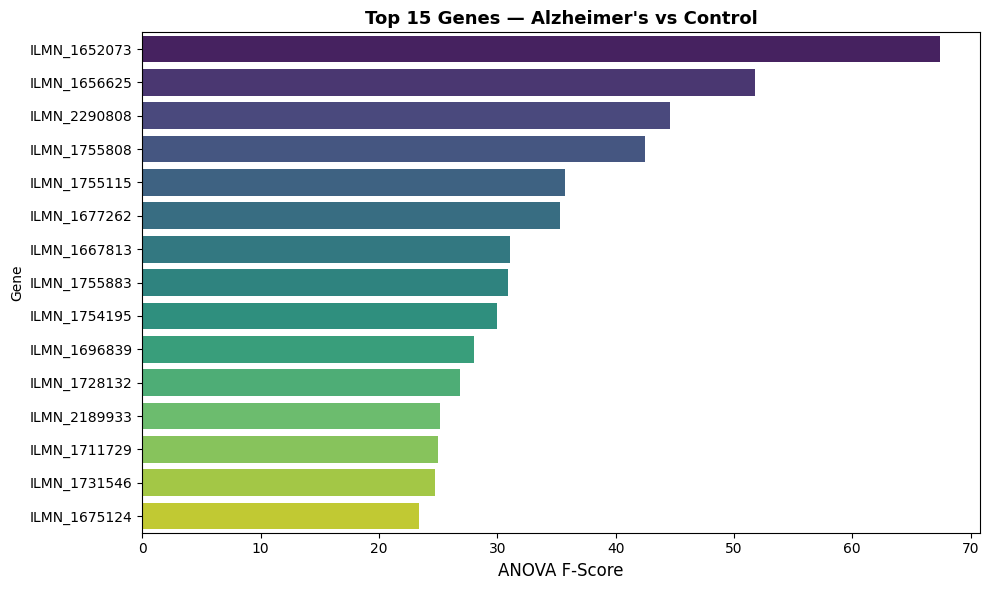

In [55]:
# Extract top genes from the selector step
selector  = best_pipeline.named_steps['selector']
mask      = selector.get_support()
top_genes = X.columns[mask]
scores_   = selector.scores_[mask]

gene_df = pd.DataFrame({
    'Gene':  top_genes,
    'Score': scores_
}).sort_values('Score', ascending=False).head(15)

print("Top 15 Genes by ANOVA F-Score:")
print(gene_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Score', y='Gene', data=gene_df, palette='viridis', ax=ax)
ax.set_title("Top 15 Genes — Alzheimer's vs Control",
             fontsize=13, fontweight='bold')
ax.set_xlabel('ANOVA F-Score', fontsize=12)
plt.tight_layout()
print("Note: ILMN_* are Illumina probe IDs — map to gene symbols via annotation file if needed")
plt.show()


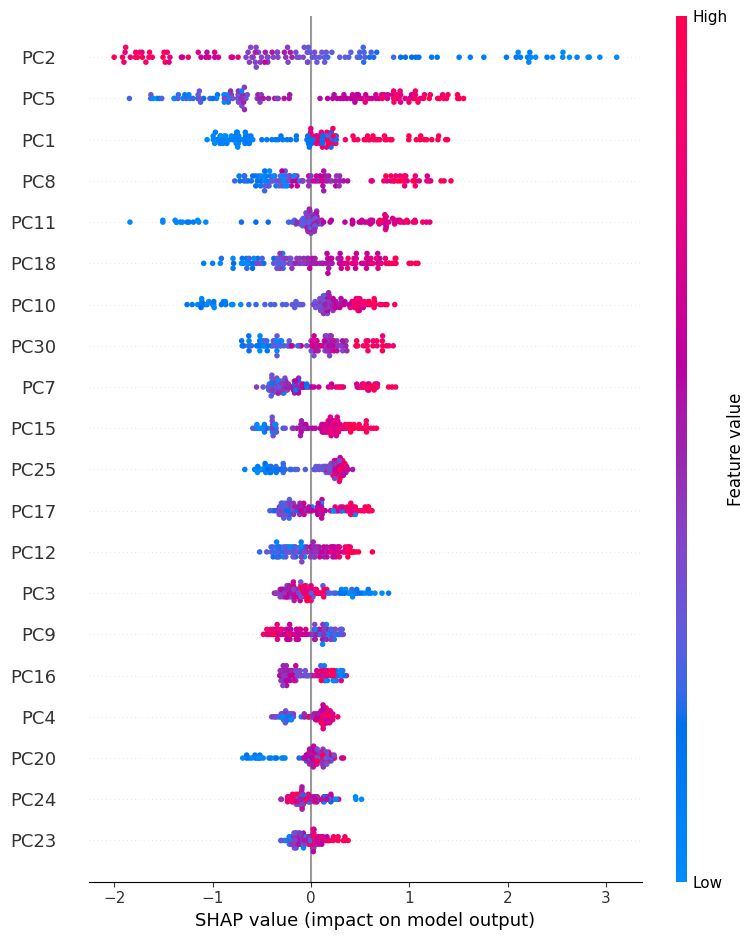

✓ SHAP summary plot shown!


In [56]:
try:
    import shap

    # Transform test data through selector + scaler + PCA steps
    X_test_transformed = best_pipeline.named_steps['selector'].transform(X_test)
    X_test_transformed = best_pipeline.named_steps['scaler'].transform(X_test_transformed)
    X_test_pca         = best_pipeline.named_steps['pca'].transform(X_test_transformed)

    explainer   = shap.TreeExplainer(best_pipeline.named_steps['xgb'])
    shap_values = explainer.shap_values(X_test_pca)

    plt.figure()
    shap.summary_plot(shap_values, X_test_pca,
                      feature_names=[f'PC{i+1}' for i in range(X_test_pca.shape[1])],
                      show=True)
    print("✓ SHAP summary plot shown!")
except ImportError:
    print("⚠ SHAP not installed. Run: pip install shap")
except Exception as e:
    print(f"⚠ SHAP error: {e}")


In [57]:
joblib.dump(best_pipeline, 'gene_xgb_pipeline.pkl')
joblib.dump(X.columns.tolist(), 'gene_feature_names.pkl')

print("✓ Model saved:")
print("  📁 gene_xgb_pipeline.pkl    (Full pipeline: selector + scaler + PCA + XGBoost)")
print("  📁 gene_feature_names.pkl   (Gene names for alignment)")


✓ Model saved:
  📁 gene_xgb_pipeline.pkl    (Full pipeline: selector + scaler + PCA + XGBoost)
  📁 gene_feature_names.pkl   (Gene names for alignment)
